In [23]:
import bioframe as bf
import pandas as pd
import numpy as np
import bbi
import matplotlib.pyplot as plt

In [24]:
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from matplotlib.ticker import FuncFormatter, FixedLocator

In [25]:
DE_Lange_Spo11_file = pd.read_excel(r'/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/NIHMS819055-supplement-9_Spo11_de_Lange.xlsx', engine='openpyxl', skiprows=8)

/users/uladzis.khauratovich/.conda/envs/night/lib/python3.8/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [26]:
DE_Lange_Spo11_file = DE_Lange_Spo11_file[
    DE_Lange_Spo11_file['chr'].str.contains('chr4_JH584292_random|chrUn_GL456370|chrUn_JH584304|chrUn_GL456389|chr4_GL456216_random|chrUn_GL456392') == False
    ].copy()
DE_Lange_Spo11_file = DE_Lange_Spo11_file.reset_index(drop=True)

In [27]:
DE_Lange_Spo11_file

,chr,Start,End,Length,Hits,center,median
0,chr1,3125995,3126157,163,11.948877,3126076,3126081
1,chr1,3658573,3658719,147,13.943932,3658653,3658651
2,chr1,3668586,3668615,30,1.694724,3668599,3668609
3,chr1,4609787,4610613,827,40.330142,4610284,4610289
4,chr1,4769620,4769710,91,7.465367,4769661,4769661
...,...,...,...,...,...,...,...
13940,chrY,90760317,90762354,2038,49.447328,90761316,90761504
13941,chrY,90788032,90788879,848,9.739300,90788844,90788599
13942,chrY,90797454,90799808,2355,72.143759,90798516,90798658
13943,chrY,90800966,90803427,2462,55.990250,90802820,90802377


In [29]:
annot_gtf = pd.read_csv('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/ATAC_RNA_Seq/Mus_musculus_GTF_genes_short_GRCm38_95.csv')

annot_gtf_tss = annot_gtf.copy()

annot_gtf_tss['start'] = annot_gtf.apply(lambda row: row['start'] if row['strand'] == '+' else row['end'], axis=1)

annot_gtf_tss['end'] = annot_gtf_tss['start']+1
bf.is_bedframe(annot_gtf_tss)
annot_gtf_tss['chrom'] = annot_gtf_tss['chrom'].str.replace('chr', '')
annot_gtf_tss = annot_gtf_tss[annot_gtf_tss['chrom'] != 'MT']
annot_gtf_tss.sort_values(by=['chrom', 'start'])
annot_gtf_tss = annot_gtf_tss[['chrom', 'start', 'end']]

In [30]:
bf.is_bedframe(annot_gtf_tss)

True

In [34]:
DE_Lange_Spo11_noSex = DE_Lange_Spo11_file[
    DE_Lange_Spo11_file['chr'].str.contains('chrX|chrY') == False
    ].reset_index(drop=True)

In [35]:
DE_Lange_Spo11_cov_sorted = DE_Lange_Spo11_noSex.sort_values(by=["Hits"], ascending=False).reset_index(drop=True).copy()


In [43]:
DE_Lange_Spo11_cov_sorted_2kb = (
    DE_Lange_Spo11_cov_sorted
        .assign(
            str_win2=lambda x: x['center'] - 1000,
            end_win2=lambda x: x['center'] + 1000,
                )
)

In [44]:
DE_Lange_Spo11_cov_sorted_2kb

,chr,Start,End,Length,Hits,center,median,str_win2,end_win2
0,chr1,58419422,58421171,1750,1168.758925,58420252,58420250,58419252,58421252
1,chr17,78650479,78651797,1319,1071.537541,78651146,78651136,78650146,78652146
2,chr1,33764532,33765577,1046,1036.956590,33765013,33765029,33764013,33766013
3,chr6,39639745,39640987,1243,982.596707,39640498,39640485,39639498,39641498
4,chr17,17653068,17654066,999,962.302923,17653629,17653633,17652629,17654629
...,...,...,...,...,...,...,...,...,...
13369,chr8,77169252,77169284,33,0.965349,77169272,77169264,77168272,77170272
13370,chr14,103702593,103702631,39,0.879540,103702614,103702597,103701614,103703614
13371,chr1,88624887,88624934,48,0.858088,88624910,88624911,88623910,88625910
13372,chr2,72461929,72461964,36,0.815184,72461938,72461936,72460938,72462938


In [45]:
Spo11_all_hotspots_noSex = DE_Lange_Spo11_cov_sorted_2kb[['chr', 'str_win2', 'end_win2']]
Spo11_all_hotspots_noSex.columns =['chrom', 'start', 'end']
Spo11_all_hotspots_noSex['chrom'] = Spo11_all_hotspots_noSex['chrom'].str.replace(r'chr', '', regex=True)

/tmp/ipykernel_53632/2958088208.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spo11_all_hotspots_noSex['chrom'] = Spo11_all_hotspots_noSex['chrom'].str.replace(r'chr', '', regex=True)


In [46]:
Spo11_all_hotspots_noSex_noTSS = bf.setdiff(Spo11_all_hotspots_noSex, annot_gtf_tss)

In [67]:
print(len(Spo11_all_hotspots_noSex_noTSS))

12809


In [52]:
# because hotspots are sorted based on [Spo11-oligo Hits]

Spo11_noSex_noTSS_hottest = Spo11_all_hotspots_noSex_noTSS.iloc[:1280]
#1280 (for 2kb)

In [53]:
bigWig_control_consensus = bbi.open('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Replicates_From_Date200722_results_3VS_3_FOR_FURTHER_ANALYSIS/results/bwa/mergedReplicate/bigwig/control.mRp.clN.bigWig')
bigWig_exp_consensus = bbi.open('/users/uladzis.khauratovich/groups_SLAVA/ATAC_Seq/Replicates_From_Date200722_results_3VS_3_FOR_FURTHER_ANALYSIS/results/bwa/mergedReplicate/bigwig/experimental.mRp.clN.bigWig')

In [54]:
df = Spo11_noSex_noTSS_hottest

cov_control_hot_Spo11 = bigWig_control_consensus.stackup(df['chrom'],
                                                         df['start'],
                                                         df['end'],
                                                         bins=1, summary='sum').flatten()
cov_exp_hot_Spo11 = bigWig_exp_consensus.stackup(df['chrom'],
                                                         df['start'],
                                                         df['end'],
                                                         bins=1, summary='sum').flatten()

In [55]:
Spo11_noSex_noTSS_hottest['cov_control_hot_Spo11'] = cov_control_hot_Spo11.tolist()
Spo11_noSex_noTSS_hottest['cov_exp_hot_Spo11'] = cov_exp_hot_Spo11.tolist()

/tmp/ipykernel_53632/1068006806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spo11_noSex_noTSS_hottest['cov_control_hot_Spo11'] = cov_control_hot_Spo11.tolist()
/tmp/ipykernel_53632/1068006806.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spo11_noSex_noTSS_hottest['cov_exp_hot_Spo11'] = cov_exp_hot_Spo11.tolist()


In [56]:
Spo11_noSex_noTSS_hottest['cov_change'] = Spo11_noSex_noTSS_hottest['cov_exp_hot_Spo11'] / Spo11_noSex_noTSS_hottest['cov_control_hot_Spo11']

/tmp/ipykernel_53632/1133420419.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spo11_noSex_noTSS_hottest['cov_change'] = Spo11_noSex_noTSS_hottest['cov_exp_hot_Spo11'] / Spo11_noSex_noTSS_hottest['cov_control_hot_Spo11']


In [57]:
Spo11_noSex_noTSS_hottest.replace([np.inf, -np.inf], np.nan, inplace=True)
# Drop rows with NaN
Spo11_noSex_noTSS_hottest.dropna(inplace=True)

Spo11_noSex_noTSS_hottest_no0 = Spo11_noSex_noTSS_hottest[
    Spo11_noSex_noTSS_hottest['cov_change'] != 0].copy()

/tmp/ipykernel_53632/3029038925.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spo11_noSex_noTSS_hottest.replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipykernel_53632/3029038925.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Spo11_noSex_noTSS_hottest.dropna(inplace=True)


In [63]:
# mean fold change
np.mean(Spo11_noSex_noTSS_hottest_no0['cov_change'])

1.197121835054818

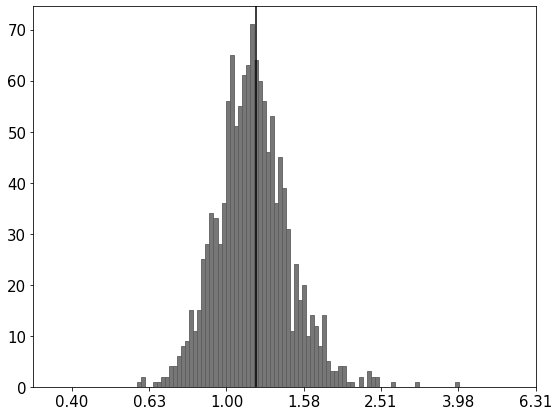

In [66]:
# ATACseq coverage change for 10% hottest DSB hotspots (+/-1kb from the center), bins overlapping TSS or from sex chromosomes are excluded

plt.figure(figsize=(9, 7))

# log10-transform 
data_log10_cov_change = np.log10(Spo11_noSex_noTSS_hottest_no0['cov_change'])

# histogram (counts on y-axis) 
plt.hist(
    data_log10_cov_change,
    bins=80,                    
    color='#5F5F5F',
    alpha=0.85,
    edgecolor='#5F5F5F',
    label='autosomal promoters',
    density=False                
)

# vertical reference lines 
plt.axvline(0.076, color='black', linestyle='solid', label='1.19')

# x-axis: show the *linear* values even though we plot in log space
def custom_tick_formatter(x, pos):
    return f'{10**x:.2f}'        # back-transform ticks

def custom_tick_locator():
    return FixedLocator(np.arange(-1, 1.4, 0.2))

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(custom_tick_formatter))
ax.xaxis.set_major_locator(custom_tick_locator())

plt.xlim(-0.5, 0.8)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.show()

#plt.savefig("Histogram_chromatin_accessibility_hottest_DSBs_noSex_noTSS_2kb_100bins.svg", dpi=300, bbox_inches="tight")